# **005 Step 1~4 Framework Setup**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

### ***Reading a file***

In [2]:
pd.read_excel("data/bluebook-for-bulldozers/Data Dictionary.xlsx")

C:\Users\HP\Desktop\ml-course-following\bulldozer-price-prediction-project\env\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Variable,Description,Unnamed: 2
0,SalesID,unique identifier of a particular sale of a ...,NaN
1,MachineID,identifier for a particular machine; machin...,NaN
2,ModelID,identifier for a unique machine model (i.e. ...,NaN
3,datasource,source of the sale record; some sources are...,NaN
4,auctioneerID,"identifier of a particular auctioneer, i.e. ...",NaN
5,YearMade,year of manufacturer of the Machine,NaN
6,MachineHoursCurrentMeter,current usage of the machine in hours at tim...,NaN
7,UsageBand,"value (low, medium, high) calculated compari...",NaN
8,Saledate,time of sale,NaN
9,Saleprice,cost of sale in USD,NaN


# **006 Exploring Our Data**

### **Importing TrainAndValid.csv**

In [3]:
df = pd.read_csv("data/bluebook-for-bulldozers/TrainAndValid.csv", low_memory=False)
# We used low_memory=False bcos of the warning given to us when we dont have low_memory=False

### **Getting info on df**

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   412698 non-null  int64  
 1   SalePrice                 412698 non-null  float64
 2   MachineID                 412698 non-null  int64  
 3   ModelID                   412698 non-null  int64  
 4   datasource                412698 non-null  int64  
 5   auctioneerID              392562 non-null  float64
 6   YearMade                  412698 non-null  int64  
 7   MachineHoursCurrentMeter  147504 non-null  float64
 8   UsageBand                 73670 non-null   str    
 9   saledate                  412698 non-null  str    
 10  fiModelDesc               412698 non-null  str    
 11  fiBaseModel               412698 non-null  str    
 12  fiSecondaryDesc           271971 non-null  str    
 13  fiModelSeries             58667 non-null   str    
 14 

### **Checking for missing values in dataset**

In [5]:
df.isna().sum()

SalesID                          0
SalePrice                        0
MachineID                        0
ModelID                          0
datasource                       0
auctioneerID                 20136
YearMade                         0
MachineHoursCurrentMeter    265194
UsageBand                   339028
saledate                         0
fiModelDesc                      0
fiBaseModel                      0
fiSecondaryDesc             140727
fiModelSeries               354031
fiModelDescriptor           337882
ProductSize                 216605
fiProductClassDesc               0
state                            0
ProductGroup                     0
ProductGroupDesc                 0
Drive_System                305611
Enclosure                      334
Forks                       214983
Pad_Type                    331602
Ride_Control                259970
Stick                       331602
Transmission                224691
Turbocharged                331602
Blade_Extension     

### **Let's plot**
***Since we're trying to predict sale price and we know that our data is a time series, it's good to plot. What we might want to look at is smth like comparing sale dates with sale price***

***Now since the data is much, it might pose an issue for our computer to draw scattered dots, so we might just take 1000 samples to draw the plot***

In [6]:
df.columns

Index(['SalesID', 'SalePrice', 'MachineID', 'ModelID', 'datasource',
       'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'UsageBand',
       'saledate', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc',
       'fiModelSeries', 'fiModelDescriptor', 'ProductSize',
       'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc',
       'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control',
       'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension',
       'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics',
       'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size',
       'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow',
       'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb',
       'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type',
       'Travel_Controls', 'Differential_Type', 'Steering_Controls'],
      dtype='str')

## **ChatGpt helping me to know what to plot:**
***Since u're working with the Buldozer Sales dataset and trying to predict `SalePrice`, there are several useful things u can plot.***

***The main idea is to look for relationships btw features and `SalePrice` i.e what affects `SalePrice`***

### **1. Sale date vs Sale price:**


***We parse the below bcos we want pandas to treat `saledate` column as actual  dates instead of plain test(i.e string)***

In [19]:
df = pd.read_csv("data/bluebook-for-bulldozers/TrainAndValid.csv",
                low_memory=False,
                parse_dates=["saledate"]
                )
df["saledate"][:1000]

0     2006-11-16
1     2004-03-26
2     2004-02-26
3     2011-05-19
4     2009-07-23
         ...    
995   2009-07-16
996   2007-06-14
997   2005-09-22
998   2005-07-28
999   2011-06-16
Name: saledate, Length: 1000, dtype: datetime64[us]

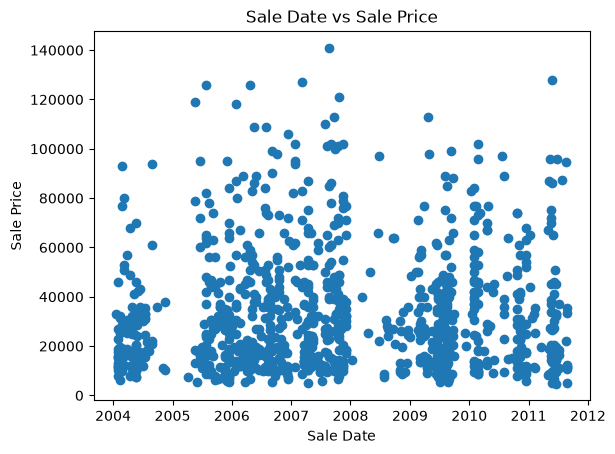

In [20]:
# Remeber we use plt.show() or a ';' after the last code
fig, ax = plt.subplots()
ax.scatter(df["saledate"][:1000], df["SalePrice"][:1000]);

ax.set_xlabel("Sale Date")
ax.set_ylabel("Sale Price")
ax.set_title("Sale Date vs Sale Price");

### **2. Machine Year vs Sale Price**

**This is checking:**

> ***Do newer bulldozers generally sell for more?***

***You may notice that newer machines tend to have higher prices, although there will probably be a lot of variation.***

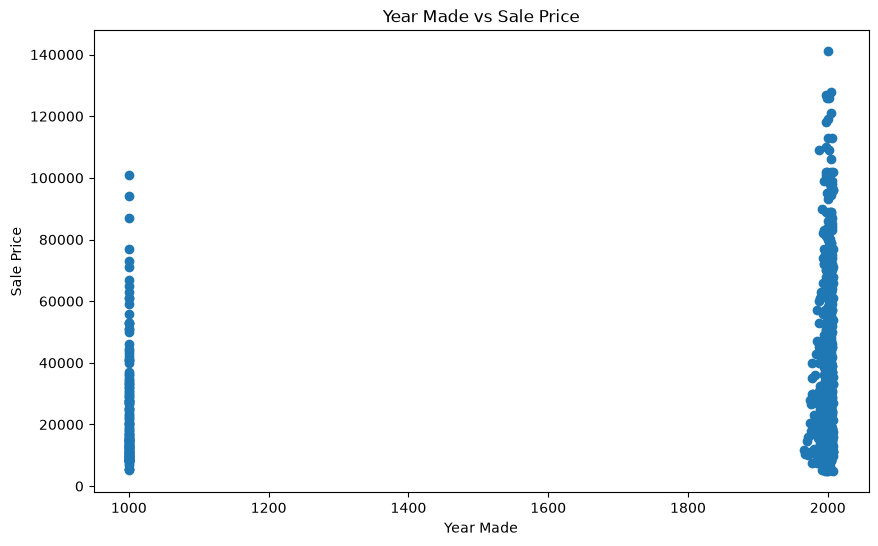

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df["YearMade"][:1000], df["SalePrice"][:1000])

ax.set_xlabel("Year Made")
ax.set_ylabel("Sale Price")
ax.set_title("Year Made vs Sale Price")

plt.show()

***Now the irregular plot above shows that around `1000 and 2000` on the YearMade axis, that bulldozers obviously weren't manufactured in years `1000 and 2000`***

***The `YearMade` column contains bad/special values, particularly `1000`.***

***In the Bulldozer dataset, 1000 is essentially being used as a placeholder for unknown/missing year information. Hence the type of graph we have above***

### **Let's check it by doing the below:**
***We will probably see `1000` in the YearMade***

In [22]:
df["YearMade"].value_counts().head(20)

YearMade
1000    39391
2005    22096
1998    21751
2004    20914
1999    19274
1997    19269
2000    17238
1996    17001
1995    15806
2003    14661
1994    14471
2006    13426
2001    13385
2002    12473
1993    11181
1989    10785
1988    10546
1990    10379
1987    10191
1992     7711
Name: count, dtype: int64

In [23]:
df["YearMade"].min()

np.int64(1000)

#### **Why is this useful?**

***This is exactly why we explore the dataset before modelling.***

***You have discovered that:***

> ***YearMade contains an invalid/placeholder value of 1000.***

***Later, when we're cleaning the data, we'll need to decide how to handle those values.***

***For now, don't delete or replace them just because the plot looks strange. You're still in the exploration stage.***

***You can make a cleaner exploratory plot by temporarily excluding the 1000 values:***

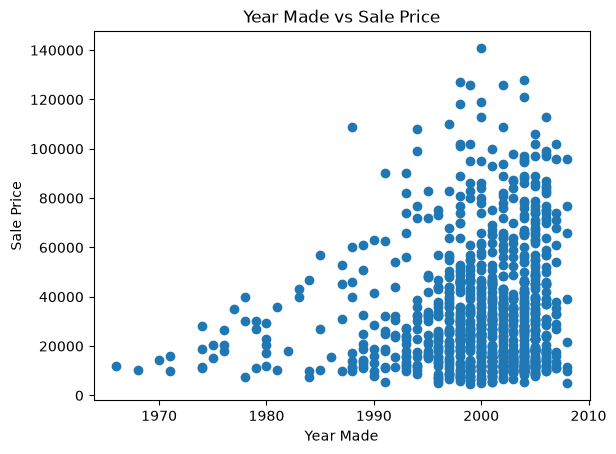

In [24]:
year_price = df[df["YearMade"] != 1000]

fig, ax = plt.subplots()
ax.scatter(
    year_price["YearMade"][:1000],
    year_price["SalePrice"][:1000]
)

ax.set_xlabel("Year Made")
ax.set_ylabel("Sale Price")
ax.set_title("Year Made vs Sale Price");

### **3. Machine Hours vs Sale Price**

**Look for columns related to usage.**

**This checks:**

> ***Does a machine with more hours tend to sell for less?***

***This is similar to mileage on a car.***

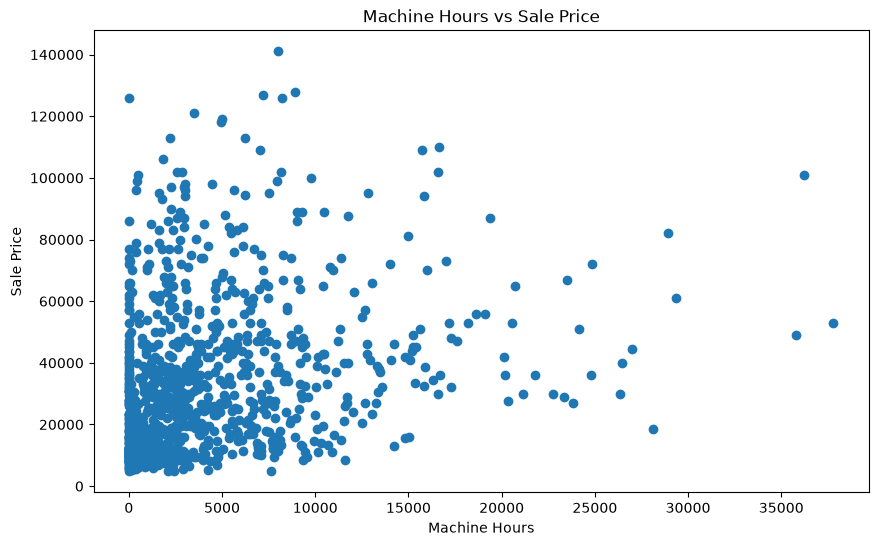

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    df["MachineHoursCurrentMeter"][:1000],
    df["SalePrice"][:1000]
)

ax.set_xlabel("Machine Hours")
ax.set_ylabel("Sale Price")
ax.set_title("Machine Hours vs Sale Price");

### **4. Year Made vs Machine Hours**

***This isn't directly about price, but it helps you understand the machines.***

**You're asking:**

> ***Are older machines generally more heavily used?***

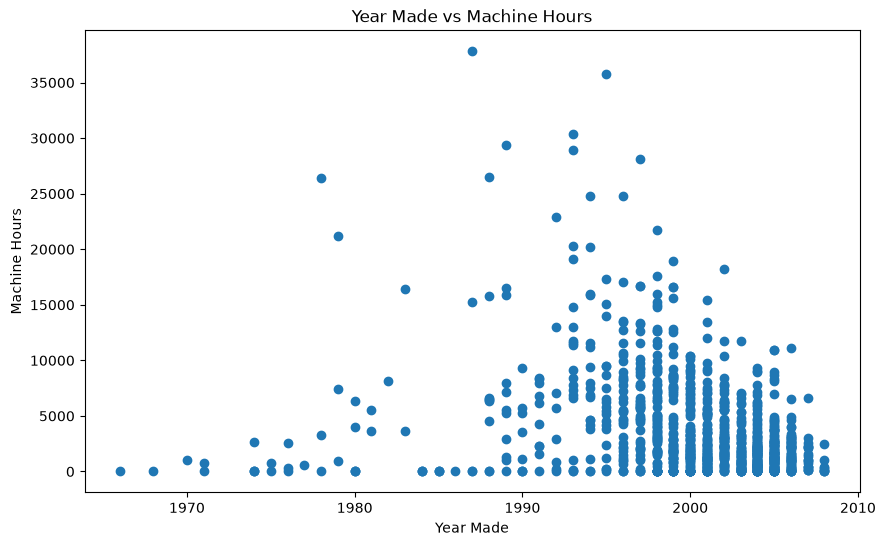

In [27]:
# First removing the year = 1000, so we do not get an irregular plot
year_price = df[df["YearMade"] != 1000]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    year_price["YearMade"][:1000],
    year_price["MachineHoursCurrentMeter"][:1000]
)

ax.set_xlabel("Year Made")
ax.set_ylabel("Machine Hours")
ax.set_title("Year Made vs Machine Hours");

### **5. Product Size vs Sale Price**

***There is a ProductSize column.***

**a) First, inspect it:**

In [30]:
df["ProductSize"].value_counts()

ProductSize
Medium            64342
Large / Medium    51297
Small             27057
Mini              25721
Large             21396
Compact            6280
Name: count, dtype: int64

**b) Then you can compare the average price:**

**This is very useful because you might discover something like:**

> ***Larger machines generally have higher sale prices.***

In [32]:
df.groupby("ProductSize")["SalePrice"].mean().sort_values()

ProductSize
Mini              15194.647720
Compact           17498.578822
Small             32511.164061
Large             42023.433315
Medium            45703.873473
Large / Medium    47828.923231
Name: SalePrice, dtype: float64

### **6. Enclosure vs Sale Price**

**There is an Enclosure column.**

***a) Check:***

In [36]:
df["Enclosure"].value_counts()

Enclosure
OROPS                  177971
EROPS                  141769
EROPS w AC              92601
EROPS AC                   18
NO ROPS                     3
None or Unspecified         2
Name: count, dtype: int64

***b) Then do the below: This helps you see whether different enclosure types are associated with different prices.***


In [37]:
df.groupby("Enclosure")["SalePrice"].mean().sort_values()

Enclosure
None or Unspecified    16500.000000
OROPS                  22592.082739
EROPS AC               23500.000000
EROPS                  28687.993278
NO ROPS                44333.333333
EROPS w AC             51671.169728
Name: SalePrice, dtype: float64

### **7. Transmission vs Sale Price**

**You can do the same thing with Transmission:**

In [38]:
df["Transmission"].value_counts()

Transmission
Standard               143915
None or Unspecified     23889
Powershift              11991
Powershuttle             4286
Hydrostatic              3342
Direct Drive              422
Autoshift                 118
AutoShift                  44
Name: count, dtype: int64

**Then:**

In [39]:
df.groupby("Transmission")["SalePrice"].mean().sort_values()

Transmission
Direct Drive            18675.829384
Powershuttle            19264.930938
Standard                28364.132218
Autoshift               33141.949153
Hydrostatic             34705.814183
Powershift              38574.352931
None or Unspecified     47354.812968
AutoShift              102261.363636
Name: SalePrice, dtype: float64

### **8. Model ID vs Sale Price**

**This can be particularly interesting:**

**This tells you:**

> ***Which machine models have historically sold for the highest average prices?***

***However, there are thousands of ModelIDs, so don't try to make a huge plot of all of them.***

In [41]:
df.groupby("ModelID")["SalePrice"].mean().sort_values(ascending=False).head(20)

ModelID
3352     136000.000000
18226    135000.000000
18228    131400.000000
14443    128200.000000
24276    125000.000000
16364    124000.000000
22714    120000.000000
3372     118865.384615
1660     115833.333333
22019    114285.714286
30567    114045.454545
18223    113733.333333
14427    112520.833333
14406    111978.723404
1630     111275.000000
2771     110662.162162
3375     110428.571429
28028    110000.000000
25555    109000.000000
11937    108750.000000
Name: SalePrice, dtype: float64

### **Check the distribution of SalePrice itself**

**This is one I definitely recommend.**

**You're trying to understand:**

> ***What does the target variable actually look like?***

***You may find that most bulldozers sell at relatively lower prices while a smaller number sell for very high prices.***

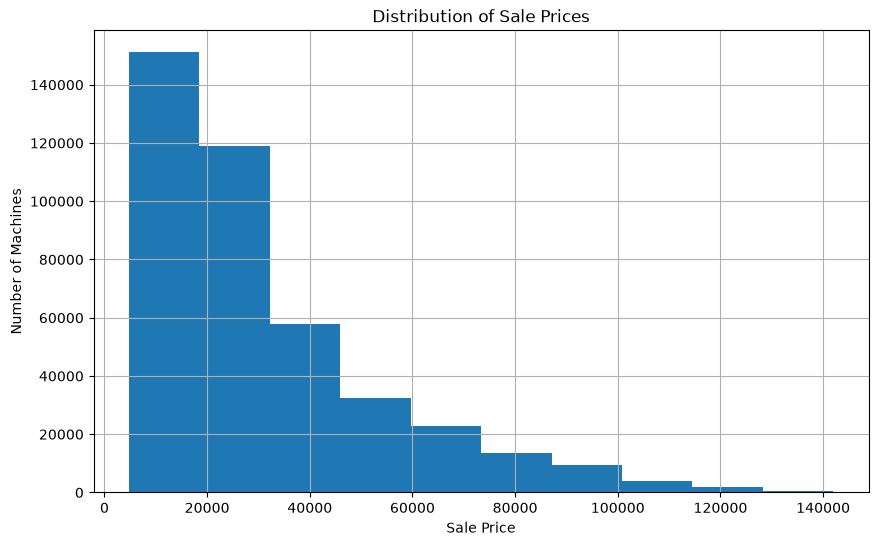

In [42]:
df["SalePrice"].hist(figsize=(10, 6))

plt.xlabel("Sale Price")
plt.ylabel("Number of Machines")
plt.title("Distribution of Sale Prices");